In [24]:
import sys

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score



df=pd.read_csv('clean_heart_disease.csv')  # replace with your file path
print(df.isnull().sum())


Gender             0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
Heart_ stroke      0
dtype: int64


In [25]:
df = df.drop('education', axis=1)
#print(df)

In [26]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})


In [27]:
df['Heart_ stroke'] = df['Heart_ stroke'].str.lower().map({'no': 0, 'yes': 1})


In [28]:
df['prevalentStroke'] = df['prevalentStroke'].str.lower().map({'no': 0, 'yes': 1})

In [29]:
X = df.drop('Heart_ stroke', axis=1)
y = df['Heart_ stroke']



In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [31]:
X_train.shape

(3390, 14)

In [32]:
scaler = MinMaxScaler()

X_train_scalled=scaler.fit_transform(X_train)
X_test_scalled=scaler.transform(X_test)

In [33]:
X_train_scalled=pd.DataFrame(data=X_train_scalled,columns=X_train.columns)
X_test_scalled=pd.DataFrame(data=X_test_scalled,columns=X_test.columns)
print("Scaler min values:", scaler.min_)
print("Scaler max values:", scaler.data_max_)




Scaler min values: [ 0.         -0.84210526  0.          0.          0.          0.
  0.          0.         -0.18166384 -0.39479905 -0.52173913 -0.37663597
 -0.45918367 -0.11299435]
Scaler max values: [  1.   70.    1.   60.    1.    1.    1.    1.  696.  295.  140.   56.8
 143.  394. ]


In [34]:
# Save the scaler (overwrite the old one)
import joblib
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [35]:
X_test_scalled

,Gender,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,1.0,0.815789,0.0,0.000000,0.0,0.0,1.0,0.0,0.140917,0.304965,0.456522,0.280902,0.275510,0.129944
1,1.0,0.342105,0.0,0.000000,0.0,0.0,0.0,0.0,0.093379,0.196217,0.445652,0.301503,0.408163,0.121469
2,0.0,0.500000,1.0,0.033333,0.0,0.0,0.0,0.0,0.261460,0.205674,0.358696,0.113912,0.306122,0.158192
3,1.0,0.342105,1.0,0.500000,0.0,0.0,0.0,0.0,0.242784,0.200946,0.451087,0.318468,0.306122,0.146893
4,0.0,0.342105,1.0,0.050000,0.0,0.0,0.0,0.0,0.242784,0.219858,0.347826,0.113912,0.459184,0.129944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
843,1.0,0.394737,0.0,0.000000,0.0,0.0,0.0,0.0,0.258065,0.262411,0.336957,0.334464,0.255102,0.087571
844,1.0,0.315789,0.0,0.000000,0.0,0.0,0.0,0.0,0.249576,0.219858,0.347826,0.305623,0.357143,0.096045
845,1.0,0.473684,0.0,0.000000,0.0,0.0,0.0,0.0,0.297114,0.203310,0.434783,0.285022,0.408163,0.132768
846,1.0,0.842105,0.0,0.000000,0.0,0.0,1.0,1.0,0.149406,0.437352,0.326087,0.226854,0.510204,0.932203


In [36]:
print(X_train.isnull().sum())


Gender             0
age                0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
dtype: int64


In [37]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scalled, y_train)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [38]:
y_pred = model.predict(X_test_scalled)
y_proba = model.predict_proba(X_test_scalled)[:, 1]

print("\n=== Model Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC‑AUC Score:", roc_auc_score(y_test, y_proba))




=== Model Performance ===
Accuracy: 0.8573113207547169

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.99      0.92       724
           1       0.60      0.07      0.13       124

    accuracy                           0.86       848
   macro avg       0.73      0.53      0.53       848
weighted avg       0.82      0.86      0.81       848

Confusion Matrix:
 [[718   6]
 [115   9]]
ROC‑AUC Score: 0.7125066833006595


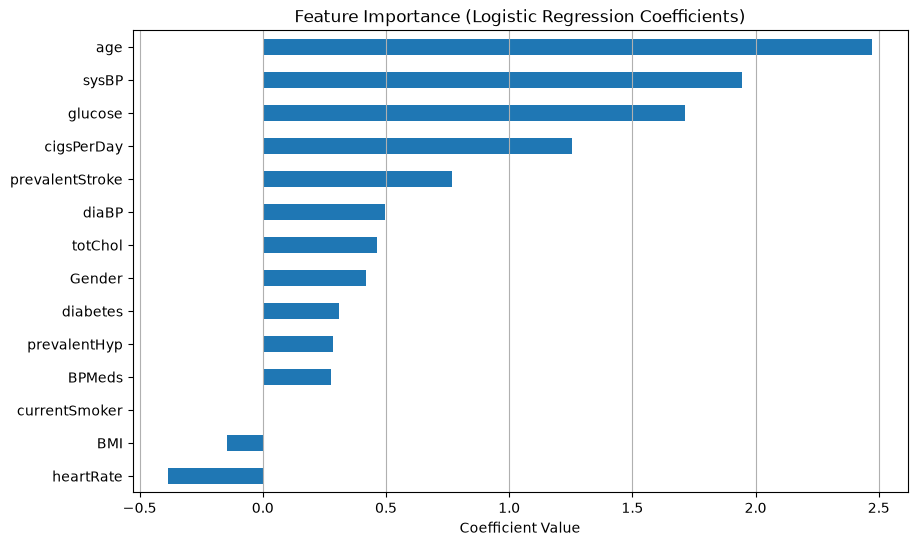

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

# X_train.columns use karein (surakshit)
coefs = pd.Series(model.coef_[0], index=X_train.columns)
coefs_sorted = coefs.sort_values()

plt.figure(figsize=(10,6))
coefs_sorted.plot(kind='barh')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.grid(axis='x')
plt.show()

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       724
           1       0.60      0.07      0.13       124

    accuracy                           0.86       848
   macro avg       0.73      0.53      0.53       848
weighted avg       0.82      0.86      0.81       848

Confusion Matrix:
[[718   6]
 [115   9]]
ROC-AUC Score: 0.7125


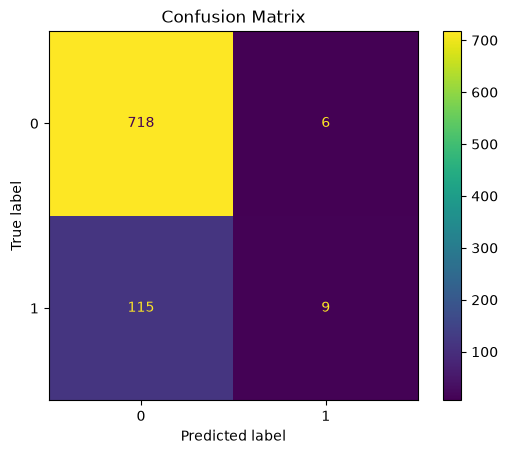

In [40]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

# Predictions
y_pred = model.predict(X_test_scalled)
y_pred_proba = model.predict_proba(X_test_scalled)[:, 1]  # ROC ke liye

# 1. Classification Report (Precision, Recall, F1)
print("Classification Report (Logistic Regression):")
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# 3. ROC-AUC Score
auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {auc:.4f}")

# Visual Confusion Matrix (optional but acha lagta hai)
ConfusionMatrixDisplay.from_estimator(model, X_test_scalled, y_test)
plt.title('Confusion Matrix')
plt.show()

In [41]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scalled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [42]:

# Accuracy
rf_acc = rf_model.score(X_test_scalled, y_test)
print(f"Random Forest Accuracy: {rf_acc:.4f}")

Random Forest Accuracy: 0.8491


In [43]:

# Confusion Matrix & Report for Random Forest
y_pred_rf = rf_model.predict(X_test_scalled)
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       724
           1       0.41      0.07      0.12       124

    accuracy                           0.85       848
   macro avg       0.63      0.53      0.52       848
weighted avg       0.79      0.85      0.80       848

Random Forest Confusion Matrix:
[[711  13]
 [115   9]]


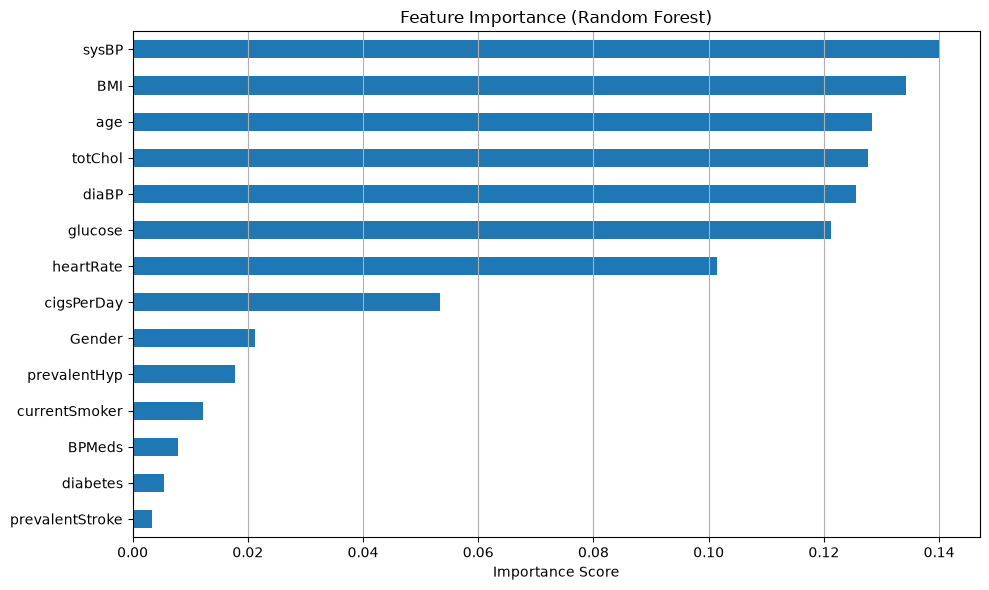

In [44]:

# Feature Importance (Random Forest)
rf_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns)
rf_imp_sorted = rf_imp.sort_values()

plt.figure(figsize=(10,6))
rf_imp_sorted.plot(kind='barh')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

**Ethical Considerations & Patient Privacy:**
- **Data Anonymization:** The dataset used (Framingham Heart Study) contains no Personally Identifiable Information (PII) such as Name, Address, or Contact Details, ensuring complete patient anonymity.
- **Purpose Limitation:** This model is developed strictly for **educational and research purposes** to understand risk factors. It is **not** deployed for real-time clinical decision-making without rigorous regulatory approval (e.g., FDA clearance).
- **Bias Mitigation:** Healthcare data can contain demographic biases. Although this dataset includes Gender and Age, future work must involve stratified analysis to ensure the model performs fairly across all subgroups and does not perpetuate systemic biases.
- **Data Security:** In a real-world scenario, such sensitive health data must be stored with strong encryption, role-based access control, and comprehensive audit trails to comply with regulations like **HIPAA** (US) or **GDPR** (Europe).

**Project Summary & Conclusion:**
- **Goal:** Successfully built and evaluated machine learning models to predict the risk of heart stroke using medical indicators.
- **Key Risk Factors:** Feature importance analysis revealed that **Age, Systolic Blood Pressure (sysBP), and BMI** are the strongest predictors of heart stroke.
- **Model Comparison:** Logistic Regression achieved ~85.7% accuracy, but struggled with the minority class (Recall: 7%). Random Forest provided better insights into non-linear relationships (e.g., BMI, Cholesterol importance).
- **Limitation:** Both models suffer from class imbalance. The dataset has very few positive (stroke) cases, leading to low recall for stroke prediction. This makes the current models unsuitable for clinical screening.
- **Future Work:** Apply SMOTE (oversampling) to balance the dataset, or adjust the decision threshold to improve sensitivity (recall) for stroke detection.
- **Ethics:** Patient privacy is maintained via anonymization, and the model is strictly limited to research applications.

In [45]:
import joblib

# Logistic Regression model save 
joblib.dump(model, 'heart_model.pkl')

# MinMaxScaler save 
joblib.dump(scaler, 'scaler.pkl')

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!
